**Importing libraries**

In [1]:
!pip install PyWavelets

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from scipy.stats import zscore

import pywt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


**Load WESAD Dataset**

In [4]:
import os

print(os.listdir("/kaggle/input/datasets/orvile"))

['wesad-wearable-stress-affect-detection-dataset']


In [5]:
DATASET_PATH = "/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD"

In [6]:
subjects=[]

for item in sorted(os.listdir(DATASET_PATH)):
    print(item)

S10
S11
S13
S14
S15
S16
S17
S2
S3
S4
S5
S6
S7
S8
S9
wesad_readme.pdf


**ignore the pdf file**

In [7]:
import os

subjects = sorted([
    item for item in os.listdir(DATASET_PATH)
    if item.startswith("S") and os.path.isdir(os.path.join(DATASET_PATH, item))
])

print(subjects)

['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


**Function for loading one subject**

In [8]:
def load_subject(subject_path):

    with open(subject_path,'rb') as file:
        data=pickle.load(file,encoding='latin1')

    return data

In [9]:
subject="S2"

path=os.path.join(DATASET_PATH,
                  subject,
                  subject+".pkl")

data=load_subject(path)

In [10]:
print(data.keys())

dict_keys(['signal', 'label', 'subject'])


In [11]:
# from wrist signal
print(data['signal']['wrist'].keys())

dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


**Preprocessing**

In [12]:
# Butterworth Bandpass Filter
from scipy.signal import butter

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order,
                  [low, high],
                  btype='band')

    return b, a

In [13]:
#filtering function
def bandpass_filter(signal,
                    fs=64,
                    lowcut=0.5,
                    highcut=5):

    b,a=butter_bandpass(lowcut,
                        highcut,
                        fs)

    filtered=filtfilt(b,
                      a,
                      signal)

    return filtered

In [14]:
#Normalization
def normalize(signal):

    return zscore(signal)

In [15]:
#combined preprocessing
def preprocess_ppg(ppg):

    filtered = bandpass_filter(ppg)

    normalized = normalize(filtered)

    return filtered, normalized

In [16]:
# Test preprocessing

ppg=data['signal']['wrist']['BVP']

ppg=ppg.squeeze()

filtered_ppg, normalized_ppg = preprocess_ppg(ppg)

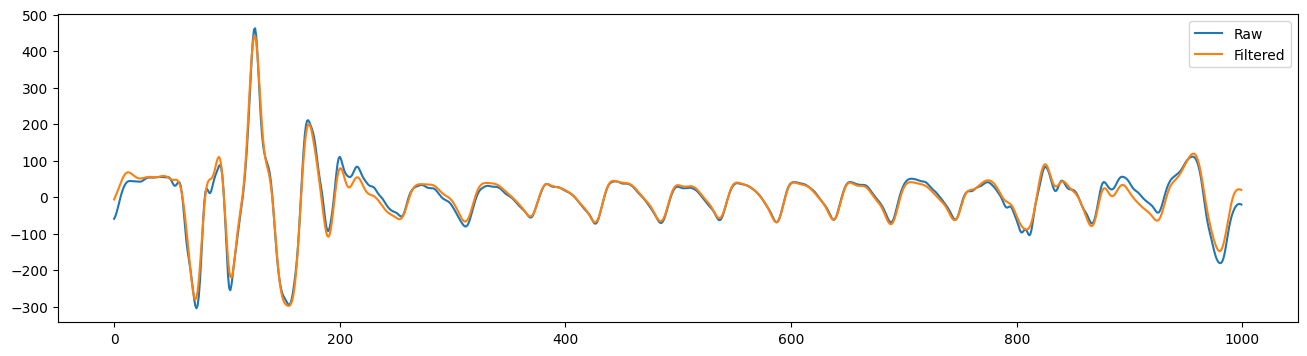

In [17]:
plt.figure(figsize=(16,4))
plt.plot(ppg[:1000], label="Raw")
plt.plot(filtered_ppg[:1000], label="Filtered")
plt.legend()
plt.show()

In [18]:
#Load PPG and Labels
import numpy as np
from scipy.interpolate import interp1d

# Load PPG
ppg = data['signal']['wrist']['BVP'].squeeze()

# Load original labels (700 Hz)
labels = data['label'].squeeze()

print("Original PPG length:", len(ppg))
print("Original Labels length:", len(labels))

Original PPG length: 389056
Original Labels length: 4255300


In [19]:

# Preprocess PPG
filtered_ppg, normalized_ppg = preprocess_ppg(ppg)

# We'll use the normalized signal for training
ppg = normalized_ppg

In [20]:
# Resample Labels from 700 Hz → 64 Hz
old_index = np.arange(len(labels))
new_index = np.linspace(0, len(labels) - 1, len(ppg))

f = interp1d(old_index,
             labels,
             kind='nearest')

labels_64 = f(new_index).astype(int)

print("PPG length:", len(ppg))
print("Resampled Labels length:", len(labels_64))

PPG length: 389056
Resampled Labels length: 389056


In [21]:
# Window Parameters
FS = 64

WINDOW_SIZE = 30 * FS      # 30 seconds
STEP_SIZE = 15 * FS        # 15 seconds overlap

In [22]:
#Label Mapping
def map_label(label):

    if label == 2:          # Stress
        return 1

    elif label in [1, 3, 4]:   # Baseline, amusement, meditation
        return 0

    else:                   # Ignore transition labels
        return -1

In [23]:
#Window Generator
def create_windows(ppg, labels, window_size, step):

    X = []
    Y = []

    for start in range(0, len(ppg) - window_size, step):

        end = start + window_size

        segment = ppg[start:end]

        segment_labels = labels[start:end]

        unique, counts = np.unique(segment_labels,
                                   return_counts=True)

        majority = unique[np.argmax(counts)]

        mapped = map_label(majority)

        if mapped == -1:
            continue

        X.append(segment)

        Y.append(mapped)

    return np.array(X), np.array(Y)

In [24]:
#Create Windows
X, Y = create_windows(
    ppg,
    labels_64,      # <-- IMPORTANT: use labels_64
    WINDOW_SIZE,
    STEP_SIZE
)

In [25]:
#Check Results
print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nClass Distribution:")
print(np.unique(Y, return_counts=True))

X shape: (192, 1920)
Y shape: (192,)

Class Distribution:
(array([0, 1]), array([151,  41]))


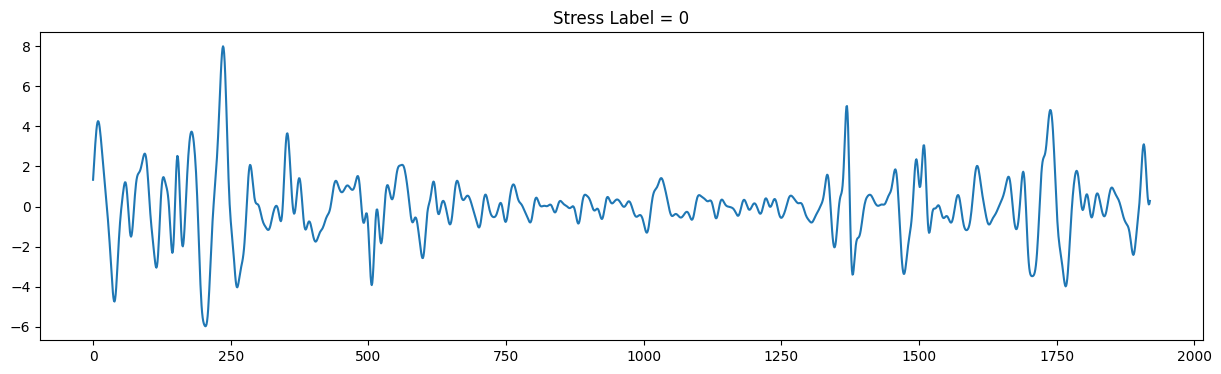

In [26]:
plt.figure(figsize=(15,4))

plt.plot(X[0])

plt.title(f"Stress Label = {Y[0]}")

plt.show()

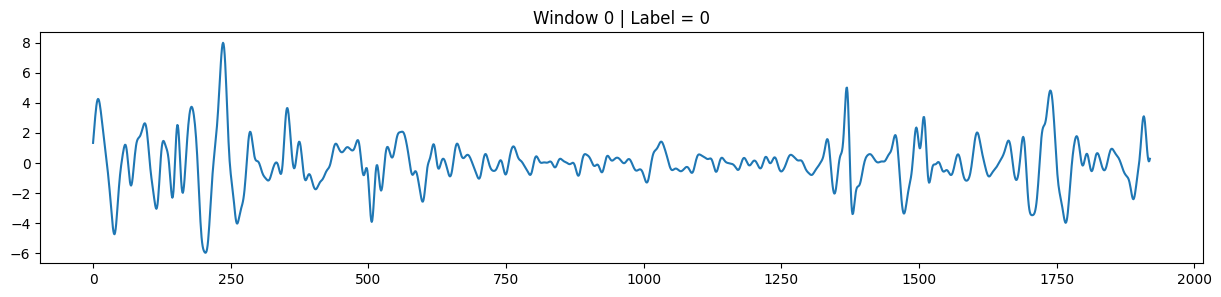

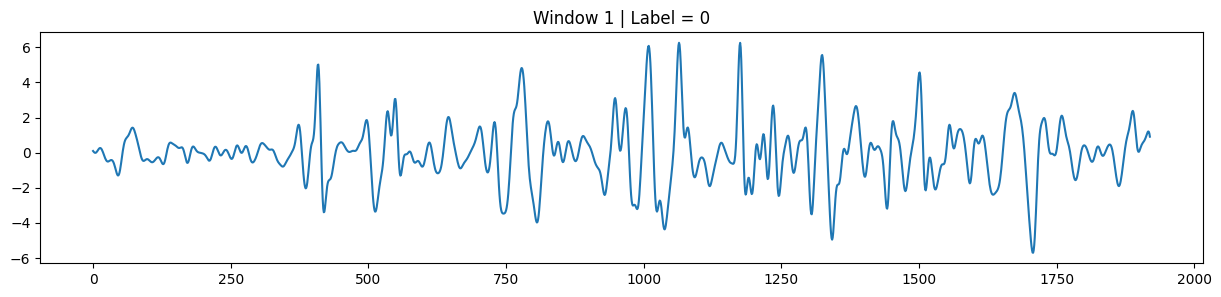

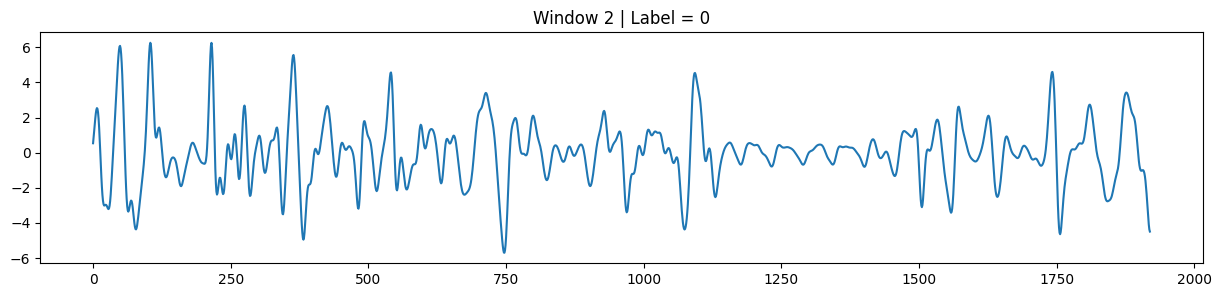

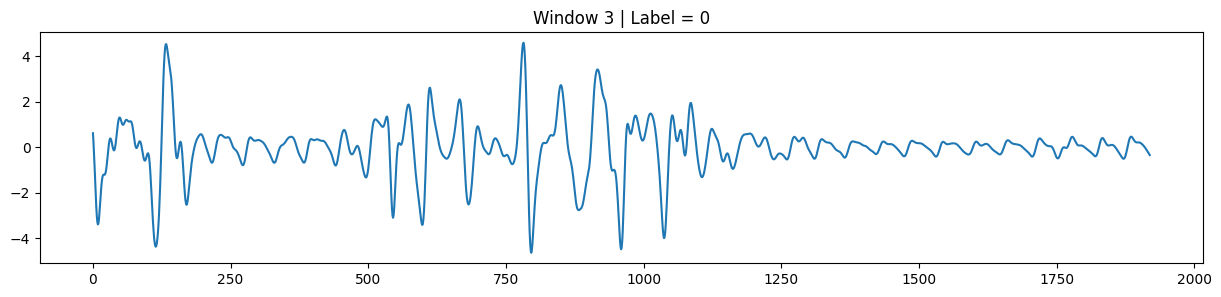

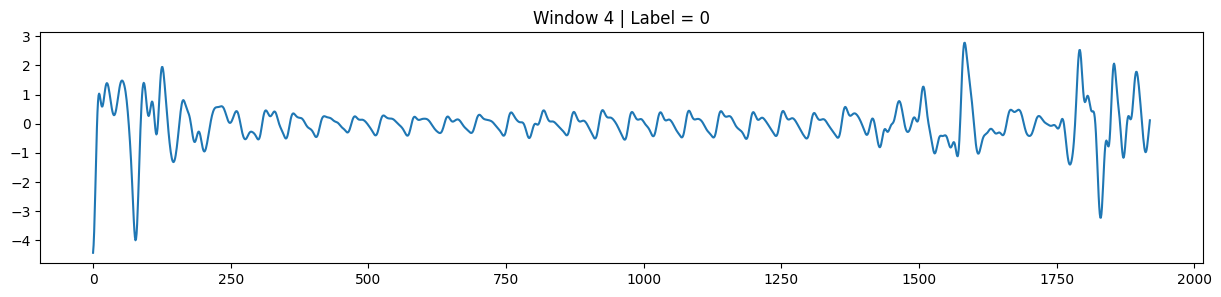

In [27]:
#verifying the labels
for i in range(5):
    plt.figure(figsize=(15,3))
    plt.plot(X[i])
    plt.title(f"Window {i} | Label = {Y[i]}")
    plt.show()

Number of stress windows: 41


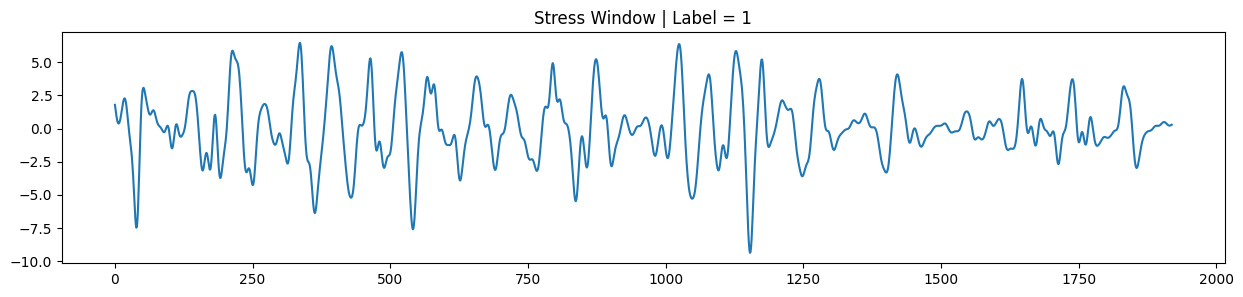

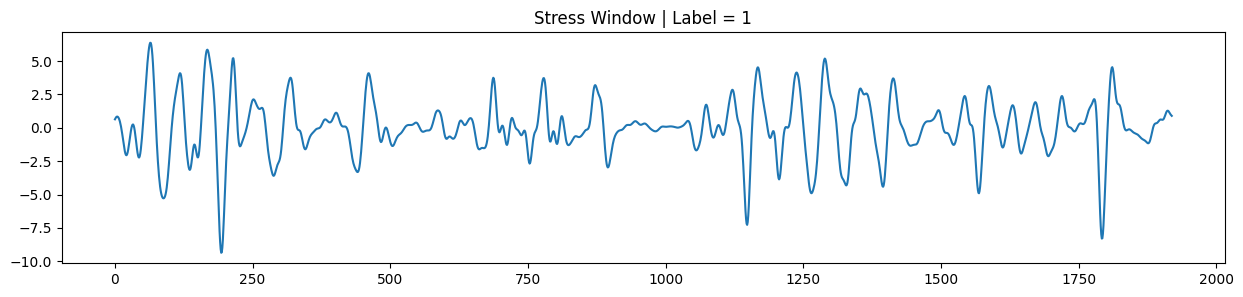

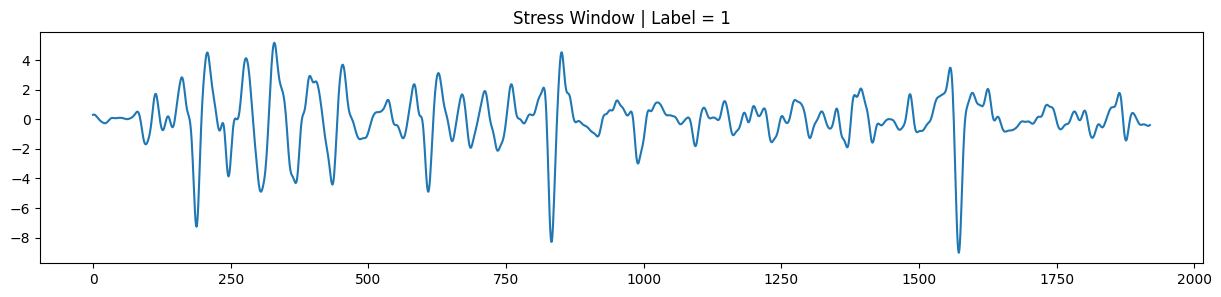

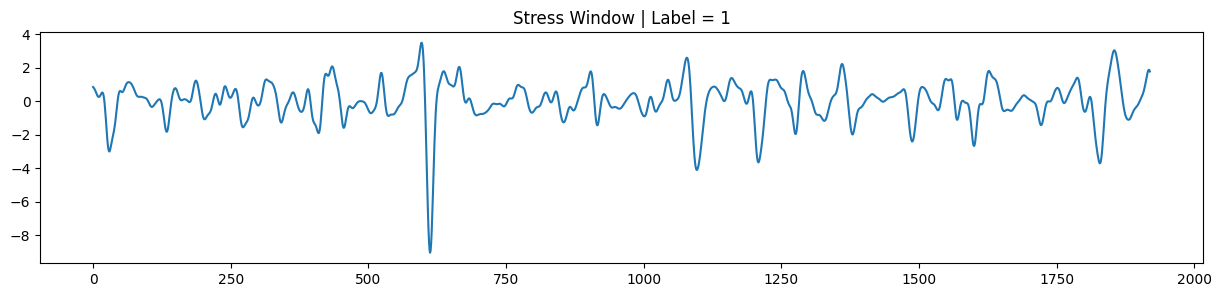

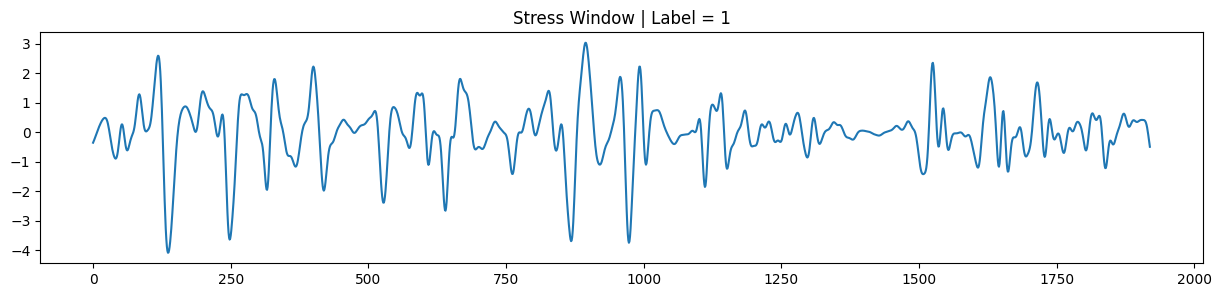

In [28]:
#stress wala graph
stress_idx = np.where(Y == 1)[0]

print("Number of stress windows:", len(stress_idx))

for i in stress_idx[:5]:
    plt.figure(figsize=(15,3))
    plt.plot(X[i])
    plt.title(f"Stress Window | Label = {Y[i]}")
    plt.show()

**Processing all subjects now**

In [29]:
subjects = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if folder.startswith("S")
])

print(subjects)

['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [30]:
X_all = []
Y_all = []

In [31]:
#loop over every subject
for subject in subjects:

    print(f"\nProcessing {subject}...")

    subject_path = os.path.join(
        DATASET_PATH,
        subject,
        subject + ".pkl"
    )

    with open(subject_path, "rb") as file:
        data = pickle.load(file, encoding="latin1")

    
    # Load BVP
    

    ppg = data['signal']['wrist']['BVP'].squeeze()

    
    # Preprocess BVP
    

    filtered_ppg, normalized_ppg = preprocess_ppg(ppg)

    ppg = normalized_ppg

    
    # Load labels
    

    labels = data['label'].squeeze()

    
    # Resample labels (700 Hz → 64 Hz)


    old_index = np.arange(len(labels))

    new_index = np.linspace(
        0,
        len(labels)-1,
        len(ppg)
    )

    f = interp1d(
        old_index,
        labels,
        kind="nearest"
    )

    labels_64 = f(new_index).astype(int)

    
    # Create windows
    

    X, Y = create_windows(
        ppg,
        labels_64,
        WINDOW_SIZE,
        STEP_SIZE
    )

    
    # Append
    

    X_all.extend(X)

    Y_all.extend(Y)

    print("Windows:", len(X))


Processing S10...
Windows: 206

Processing S11...
Windows: 202

Processing S13...
Windows: 202

Processing S14...
Windows: 202

Processing S15...
Windows: 201

Processing S16...
Windows: 200

Processing S17...
Windows: 199

Processing S2...
Windows: 192

Processing S3...
Windows: 197

Processing S4...
Windows: 197

Processing S5...
Windows: 200

Processing S6...
Windows: 199

Processing S7...
Windows: 199

Processing S8...
Windows: 200

Processing S9...
Windows: 200


In [32]:
X_all = np.array(X_all)

Y_all = np.array(Y_all)

print(X_all.shape)
print(Y_all.shape)

(2996, 1920)
(2996,)


In [33]:
#classdistribution
classes, counts = np.unique(
    Y_all,
    return_counts=True
)

print(classes)

print(counts)

[0 1]
[2329  667]


In [34]:
print("Total windows:", len(X_all))

print("Window length:", X_all.shape[1])

print("Labels:", np.unique(Y_all))

Total windows: 2996
Window length: 1920
Labels: [0 1]


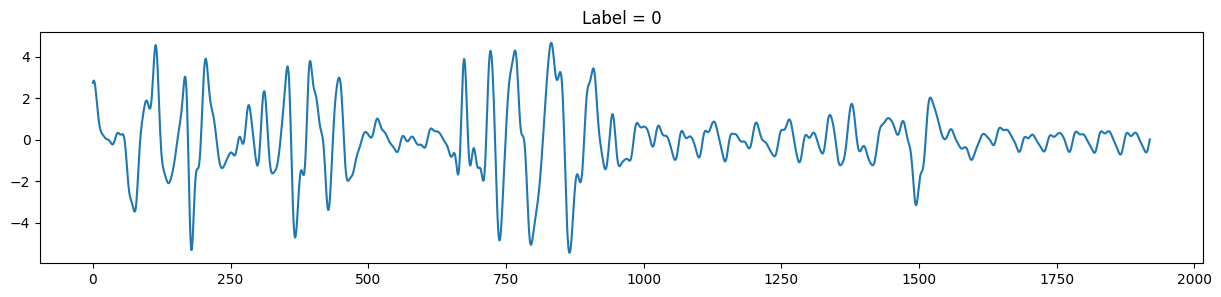

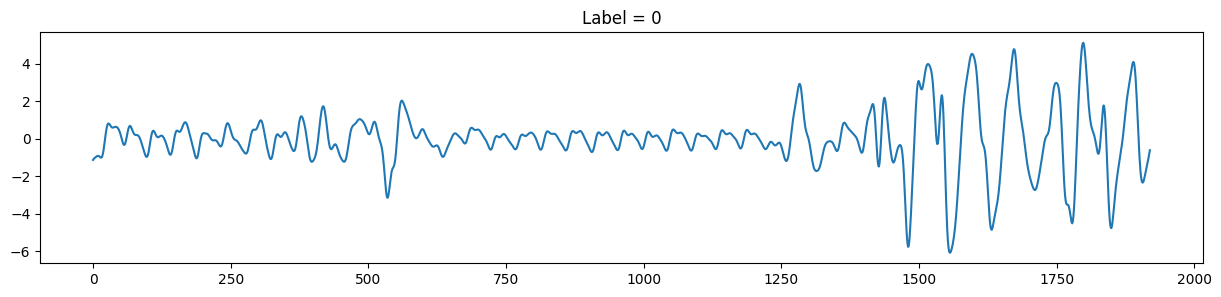

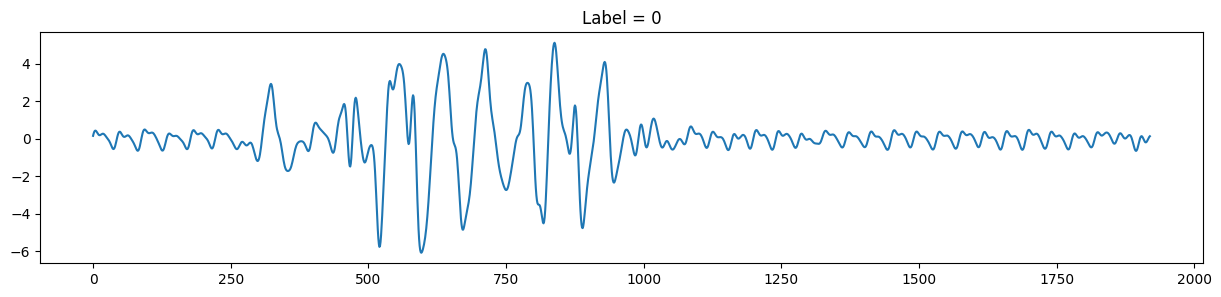

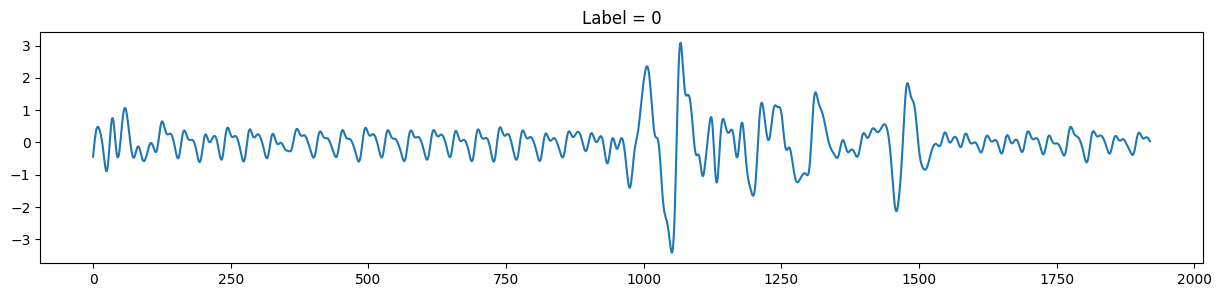

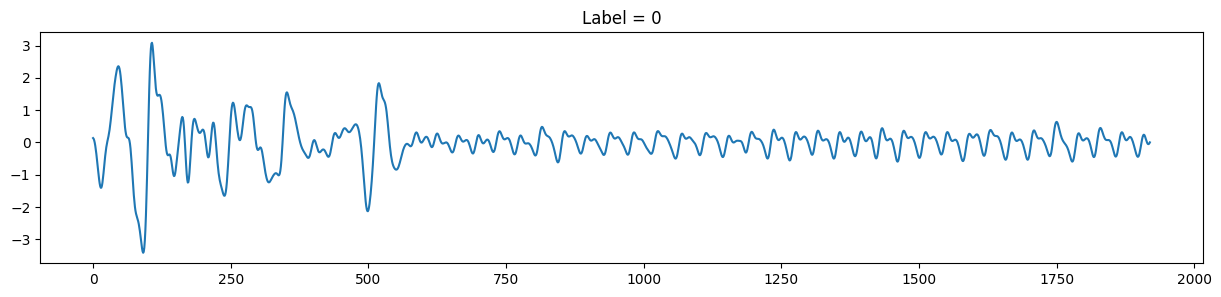

In [35]:
import matplotlib.pyplot as plt

for i in range(5):

    plt.figure(figsize=(15,3))

    plt.plot(X_all[i])

    plt.title(f"Label = {Y_all[i]}")

    plt.show()

In [36]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    Y_all,
    test_size=0.2,
    random_state=42,
    stratify=Y_all
)

print(X_train.shape)
print(X_test.shape)

(2396, 1920)
(600, 1920)


In [37]:
import numpy as np

np.save("X_all.npy", X_all)
np.save("Y_all.npy", Y_all)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!
